
# Eksploracja danych – Laboratorium 1 
## Zrozumienie i przygotowanie danych


---

### 1. Metodologia CRISP-DM

CRISP-DM (*Cross Industry Standard Process for Data Mining*) obejmuje sześć etapów:

1. **Business Understanding** – zrozumienie problemu biznesowego  
2. **Data Understanding** – zrozumienie danych  
3. **Data Preparation** – przygotowanie danych  
4. **Modeling** – budowa modeli  
5. **Evaluation** – ocena modeli  
6. **Deployment** – wdrożenie  

Niniejszy notebook realizuje etap **Data Understanding**, którego celem jest:

- opis struktury danych,
- analiza statystyczna,
- identyfikacja brakujących danych,
- wykrycie punktów oddalonych,
- analiza zależności między zmiennymi.


In [54]:

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option('display.max_columns', None)



### 2. Statystyka opisowa - teoria

#### 2.1 Średnia arytmetyczna

Średnia arytmetyczna:

μ = (1/n) * Σ xᵢ

gdzie:
- n – liczba obserwacji
- xᵢ – i-ta obserwacja

#### 2.2 Wariancja i odchylenie standardowe

Wariancja:

σ² = (1/n) * Σ (xᵢ - μ)²

Odchylenie standardowe:

σ = √σ²

Miary te opisują zmienność danych.

#### 2.3 Kwartyle

Q1 – pierwszy kwartyl (25%)  
Q2 – mediana (50%)  
Q3 – trzeci kwartyl (75%)  

IQR = Q3 − Q1

#### 2.4 Korelacja Pearsona

r = cov(X,Y) / (σₓ σᵧ)

Współczynnik przyjmuje wartości z przedziału [-1,1].



### 3. Analiza ilościowa

Zbiór danych zapisanych w pliku cars.txt zawiera informację o 261 markach samochodów wyprodukowanych w latach siedemdziesiątych i osiemdziesiątych, atrybuty mówią o zużyciu paliwa (*mpg - miles per gallon*), liczbie cylindrów (*cylinders*), pojemności silnika w calach sześciennych (*cubicinches*), liczbie koni mechanicznych (*hp - horse power*), wadze auta (*weightlbs* - waga w funtach), czasie przyspieszania do 60 mil na godzinę (*timeto-60* - w sekundach), roku debiutu na rynku (*year*) oraz kraju pochodzenia (*brand*).

In [55]:

cars = pd.read_csv("cars.txt")
cars.head()


,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350,165,4209.0,12,1972,US.
1,31.9,4,89,71,112.5,14,1980,Europe.
2,17.0,8,302,140,3449.0,11,1971,US.
3,15.0,8,400,150,3761.0,10,1971,US.
4,30.5,4,98,63,2051.0,17,1978,US.


In [56]:

cars.describe()


,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,25.116475,5.590038,201.103448,106.360153,2998.545977,15.547893,1976.819923
std,32.572908,1.733310,108.879683,40.499959,868.709300,2.910625,3.637696
min,10.000000,3.000000,68.000000,46.000000,112.500000,8.000000,1971.000000
25%,16.900000,4.000000,101.000000,75.000000,2246.000000,14.000000,1974.000000
50%,22.000000,6.000000,156.000000,95.000000,2835.000000,16.000000,1977.000000
75%,29.000000,8.000000,302.000000,138.000000,3664.000000,17.000000,1980.000000
max,534.000000,8.000000,455.000000,230.000000,4997.000000,25.000000,1983.000000



#### Interpretacja

- Porównujemy średnią i medianę w celu oceny asymetrii rozkładu.
- Wysokie odchylenie standardowe wskazuje na dużą zmienność.
- Różnice między Q1 i Q3 informują o koncentracji danych.



### 4. Analiza brakujących danych

Brakujące dane są zawsze problemem przy tworzeniu rozwiązań eksploracji danych. Należy zidentyfikować brakujące dane, a następnie podjąć decyzję co z tymi danymi, a właściwie ich brakiem zrobić.

Brakujące dane można podzielić na kilka klas: brak wartości, pusty łańcuch znaków albo wartość ustalona przez administratora. Pierwsze dwa typy brakujących wartości są zazwyczaj wychwytywane na etapie odczytywania danych. Ostatni z typów brakujących danych można wykryć używając metod identyfikacji punktów oddalonych (to zagadnienie jest opisane w punkcie dotyczącym identyfikacji punktów oddalonych).

Najczęściej stosowane metody imputacji:
- średnia / mediana,
- dominanta,
- regresja,
- KNN.

Identyfikacja brakujących danych zostanie pokazana na przykładzie zbioru danych z informacjami demograficznymi.

---

Zbiór danych zapisanych w pliku SmallSampleMissing.txt zawiera informacje demograficzne o poszczególnych osobach identyfikowanych pewnym identyfikatorem – *ID*. Atrybuty mówią o wieku - *AGE*, płci - *SEX*, typie regionu, w jakim zamieszkuje dana osoba - *REGION*, przychodzie - *INCOME*, stanie cywilnym *MARRIED*, liczbie dzieci *CHILDREN* i posiadaniu samochodu - *CAR*.

In [57]:

missing = pd.read_csv("SmallSampleMissing.txt")
missing.isnull().sum()


ID          0
AGE         0
SEX         1
REGION      0
INCOME      1
MARRIED     0
CHILDREN    0
CAR         0
dtype: int64

In [58]:
missing['SEX']=missing['SEX'].replace(missing['SEX'][2],np.nan)
#inne rozwiązanie, które sprawdzi się niezależnie od tego, czy wiemy, jaka jest wartość specjalna
#missing['SEX']=missing['SEX'].replace("MALE",1)
#missing['SEX']=missing['SEX'].replace("FEMALE",2)
#missing['SEX'] = pd.to_numeric(missing['SEX'], errors='coerce')
missing.isnull().sum()

ID          0
AGE         0
SEX         2
REGION      0
INCOME      1
MARRIED     0
CHILDREN    0
CAR         0
dtype: int64

In [59]:
missing

,ID,AGE,SEX,REGION,INCOME,MARRIED,CHILDREN,CAR
0,ID12701,23,MALE,INNER_CITY,18766,YES,1,YES
1,ID12702,30,NaN,RURAL,9915,NO,2,NO
2,ID12703,45,NaN,RURAL,21881,NO,0,YES
3,ID12704,50,MALE,TOWN,NaN,YES,2,NO
4,ID12705,41,FEMALE,INNER_CITY,,YES,0,NO
5,ID12706,20,MALE,INNER_CITY,16688,NO,1,NO
6,ID12707,46,FEMALE,RURAL,39068,YES,0,YES
7,ID12708,50,FEMALE,INNER_CITY,27740,YES,1,YES
8,ID12709,42,MALE,INNER_CITY,33584,NO,3,YES
9,ID12710,57,FEMALE,TOWN,19621,YES,99,YES


In [60]:

missing['INCOME'] = pd.to_numeric(missing['INCOME'], errors='coerce')
missing.dtypes


ID           object
AGE           int64
SEX          object
REGION       object
INCOME      float64
MARRIED      object
CHILDREN      int64
CAR          object
dtype: object

In [61]:
missing

,ID,AGE,SEX,REGION,INCOME,MARRIED,CHILDREN,CAR
0,ID12701,23,MALE,INNER_CITY,18766.0,YES,1,YES
1,ID12702,30,NaN,RURAL,9915.0,NO,2,NO
2,ID12703,45,NaN,RURAL,21881.0,NO,0,YES
3,ID12704,50,MALE,TOWN,NaN,YES,2,NO
4,ID12705,41,FEMALE,INNER_CITY,NaN,YES,0,NO
5,ID12706,20,MALE,INNER_CITY,16688.0,NO,1,NO
6,ID12707,46,FEMALE,RURAL,39068.0,YES,0,YES
7,ID12708,50,FEMALE,INNER_CITY,27740.0,YES,1,YES
8,ID12709,42,MALE,INNER_CITY,33584.0,NO,3,YES
9,ID12710,57,FEMALE,TOWN,19621.0,YES,99,YES


In [62]:

missing.fillna({'SEX': missing['SEX'].mode()[0]}, inplace=True)
missing.isnull().sum()

ID          0
AGE         0
SEX         0
REGION      0
INCOME      2
MARRIED     0
CHILDREN    0
CAR         0
dtype: int64

In [63]:
missing

,ID,AGE,SEX,REGION,INCOME,MARRIED,CHILDREN,CAR
0,ID12701,23,MALE,INNER_CITY,18766.0,YES,1,YES
1,ID12702,30,FEMALE,RURAL,9915.0,NO,2,NO
2,ID12703,45,FEMALE,RURAL,21881.0,NO,0,YES
3,ID12704,50,MALE,TOWN,NaN,YES,2,NO
4,ID12705,41,FEMALE,INNER_CITY,NaN,YES,0,NO
5,ID12706,20,MALE,INNER_CITY,16688.0,NO,1,NO
6,ID12707,46,FEMALE,RURAL,39068.0,YES,0,YES
7,ID12708,50,FEMALE,INNER_CITY,27740.0,YES,1,YES
8,ID12709,42,MALE,INNER_CITY,33584.0,NO,3,YES
9,ID12710,57,FEMALE,TOWN,19621.0,YES,99,YES


### Zadanie 1. (1 pkt)

Uzupełnij brakujące wartości w kolumnie *INCOME* wartością średnią.

In [64]:
missing["INCOME"].mean()

23407.875

In [65]:
# Miejsce na odpowiedź
missing.fillna({"INCOME": missing["INCOME"].mean() }, inplace=True)
missing

,ID,AGE,SEX,REGION,INCOME,MARRIED,CHILDREN,CAR
0,ID12701,23,MALE,INNER_CITY,18766.000,YES,1,YES
1,ID12702,30,FEMALE,RURAL,9915.000,NO,2,NO
2,ID12703,45,FEMALE,RURAL,21881.000,NO,0,YES
3,ID12704,50,MALE,TOWN,23407.875,YES,2,NO
4,ID12705,41,FEMALE,INNER_CITY,23407.875,YES,0,NO
5,ID12706,20,MALE,INNER_CITY,16688.000,NO,1,NO
6,ID12707,46,FEMALE,RURAL,39068.000,YES,0,YES
7,ID12708,50,FEMALE,INNER_CITY,27740.000,YES,1,YES
8,ID12709,42,MALE,INNER_CITY,33584.000,NO,3,YES
9,ID12710,57,FEMALE,TOWN,19621.000,YES,99,YES


#### Interpretacja

Imputacja średnią zmniejsza wariancję zmiennej.
Imputacja dominantą zwiększa liczność najczęstszej kategorii.

Należy pamiętać, że imputacja może wprowadzać bias.



### 5. Punkty oddalone

Definicja metody IQR:

Obserwacja jest punktem oddalonym, gdy:

x < Q1 − 1.5·IQR  
x > Q3 + 1.5·IQR

Punkty oddalone mogą:
- wynikać z błędów pomiarowych,
- reprezentować rzadkie, ale poprawne przypadki,
- powodować błędy w pewnych metodach statystycznych wrażliwych na punkty oddalone.

Najbardziej popularne narzędzia wykorzystywane do identyfikacji punktów oddalonych to:
- histogramy
- wykresy punktowe rozproszone (ang. scatter plot)
- wykresy pudełkowe (ang. box plot)

Do identyfikacji punktów oddalonych zostanie wykorzystany zbiór z informacją o klientach firmy telekomunikacyjnej.

---

W pliku churn.txt znajduje się zbiór danych składający się z 20 zmiennych informujących o 3333 klientach, razem ze wskazaniem, czy zrezygnowali z usług firmy (zmienna *churn*). Zmienne są następujące: - stan (*state*) – 50 stanów i Dystrykt Kolumbia, - czas współpracy (*account length*) – czas posiadania konta, - kod (*area code*) – kod obszaru, - telefon (*phone*) – telefon, - plan mędzynarodowy (*intl plan*) – czy klient przystąpił do planu międzynarodowego, - poczta głosowa (*vmail plan*) – czy klient przystąpił do planu poczty głosowej, - liczba wiadomości (*vmail message*) – liczba wiadomości w poczcie głosowej, - dzień minut (*day mins*) – liczba minut, które klient zużył w ciągu dnia, - dzień rozmowy (*day calls*) – liczba połączeń w dzień, - dzień opłata (*day charge*) – całkowita opłata za rozmowy w dzień, - wieczór minuty (*eve mins*) – całkowita liczba minut wieczorem, - wieczór rozmowy (*eve calls*) – liczba połączeń wieczorem, - wieczór opłata (*eve charge*) – całkowita opłata za rozmowy wieczorem, - noc minuty (*night mins*) – całkowita liczba minut w nocy, - noc rozmowy (*night calls*) – liczba połączeń w nocy, - noc opłata (*night charge*) – całkowita opłata za rozmowy w nocy, - międzynarodowe minuty (*intl mins*) – całkowita liczba minut na połączenia międzynarodowe, - międzynarodowe rozmowy (*intl calls*) – liczba połączeń międzynarodowych, - międzynarodowe opłaty (*intl charge*) – całkowita opłata za rozmowy w połączeniach międzynarodowych - liczba rozmów z BOK (*custServ calls*) – liczba połączeń z biurem obsługi klienta.

In [66]:

churn = pd.read_csv("churn.txt")
churn.head()


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


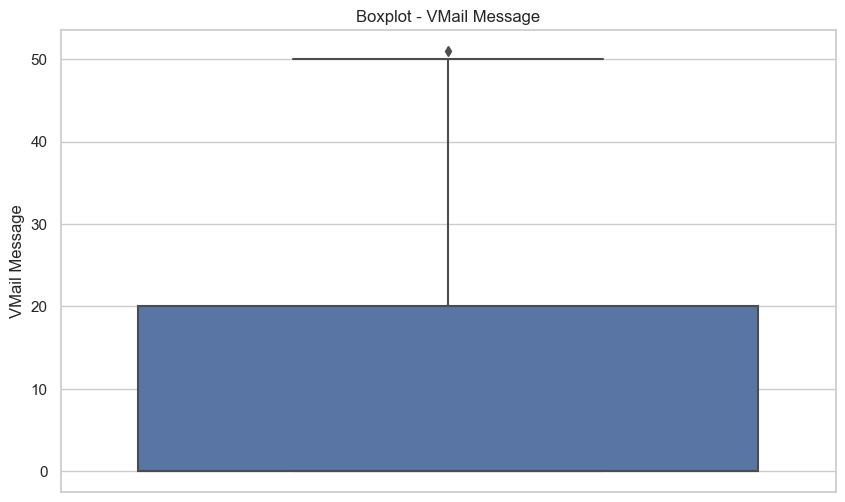

In [67]:
sns.boxplot(y=churn['VMail Message'])
plt.title("Boxplot - VMail Message")
plt.show()

In [68]:

Q1 = churn['VMail Message'].quantile(0.25)
Q3 = churn['VMail Message'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [69]:

outliers = churn[(churn['VMail Message'] < lower) | 
                 (churn['VMail Message'] > upper)]

outliers.head(20)


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
845,FL,144,415,376-4484,no,yes,51,283.9,98,48.26,192.0,109,16.32,196.3,85,8.83,10.0,4,2.7,1,False.


### Zadanie 2. (1 pkt)

Znajdź punkty oddalone dla zmiennej *Day Calls* i zwizualizuj je. Co możesz o nich powiedzieć?

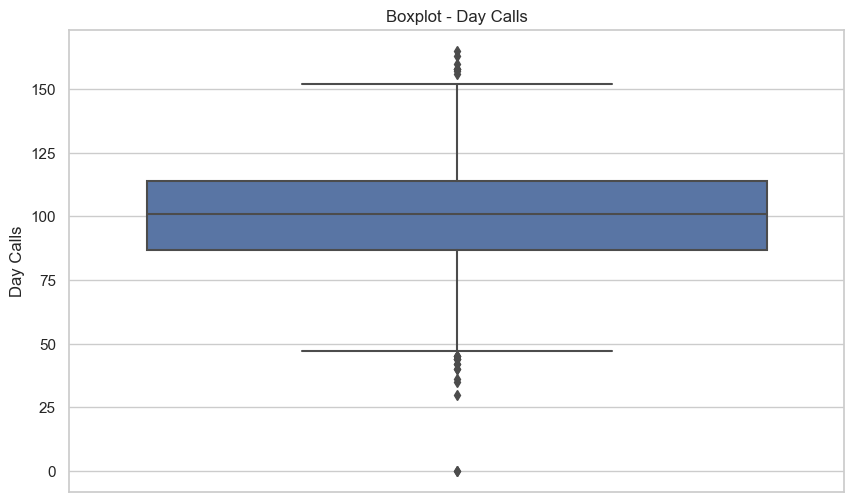

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
315,MA,39,408,332-2462,no,no,0,60.4,158,10.27,306.2,120,26.03,123.9,46,5.58,12.4,3,3.35,1,False.
468,AZ,86,415,392-2381,no,yes,32,70.9,163,12.05,166.7,121,14.17,244.9,105,11.02,11.1,5,3.00,3,False.
692,NE,82,408,343-2741,no,no,0,185.8,36,31.59,276.5,134,23.50,192.1,104,8.64,5.7,7,1.54,4,False.
740,UT,67,510,414-9027,no,yes,20,230.6,40,39.20,189.1,58,16.07,162.2,115,7.30,9.4,2,2.54,1,False.
1057,WV,86,415,332-2258,no,yes,38,123.0,158,20.91,133.9,119,11.38,138.2,103,6.22,13.3,4,3.59,1,False.
1121,MI,91,415,390-7930,no,no,0,154.4,165,26.25,168.3,121,14.31,239.9,81,10.80,11.7,4,3.16,5,True.
1144,NH,155,408,353-6300,no,no,0,216.7,30,36.84,144.3,125,12.27,135.3,106,6.09,10.8,1,2.92,2,False.
1322,DE,2,415,415-8448,yes,no,0,132.1,42,22.46,138.9,88,11.81,192.6,119,8.67,9.1,1,2.46,2,True.
1345,SD,98,415,392-2555,no,no,0,0.0,0,0.00,159.6,130,13.57,167.1,88,7.52,6.8,1,1.84,4,True.
1346,PA,106,408,403-9167,yes,no,0,133.7,45,22.73,187.8,107,15.96,181.9,89,8.19,10.7,2,2.89,1,True.


In [71]:
# Miejsce na odpowiedź

sns.boxplot(y=churn['Day Calls'])
plt.title("Boxplot - Day Calls")
plt.show()

Q1 = churn['Day Calls'].quantile(0.25)
Q3 = churn['Day Calls'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = churn[(churn['Day Calls'] < lower) | 
                 (churn['Day Calls'] > upper)]

outliers.head(20)

# Punkty są gęsto i jest ich wiele poza tym zakresem i nie powinno się ich usuwać


#### Interpretacja

Jeżeli liczba punktów oddalonych jest niewielka, 
można rozważyć ich usunięcie.

Jeżeli jednak reprezentują specyficzną grupę klientów, 
mogą mieć istotne znaczenie biznesowe.



### 6. Odkrywanie zależności pomiędzy zmiennymi

Odkrywanie korelacji pomiędzy zmiennymi w zbiorze danych jest jedną z najciekawszych i najważniejszych czynności wykonywanych w ramach EDA. Jest także ważne z punktu widzenia przygotowania danych do dalszej analizy, gdyż są przypadki, kiedy duża liczba skorelowanych atrybutów może zaburzyć wyniki.

Popularne narzędzia wykorzystywane do wykrywania skorelowanych zmiennych to macierz korelacji, macierze wykresów punktowych i regresja.

#### 6.1. Analiza zmiennych skorelowanych z wykorzystaniem macierzy korelacji 

Macierz korelacji pozwala zidentyfikować 
najsilniejsze zależności między zmiennymi ilościowymi.


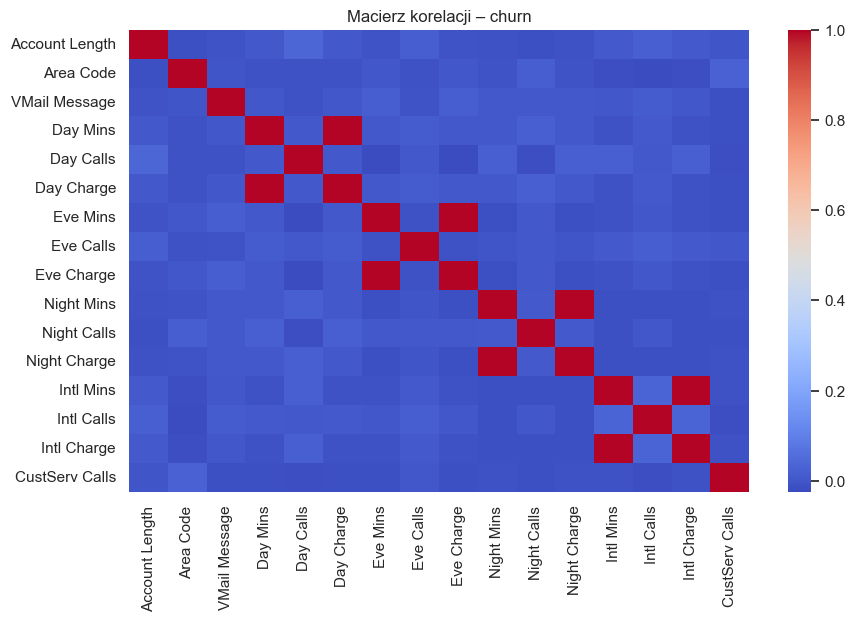

In [72]:

corr_churn = churn.corr(numeric_only=True)
sns.heatmap(corr_churn, cmap="coolwarm")
plt.title("Macierz korelacji – churn")
plt.show()



#### Interpretacja

Silne korelacje między zmiennymi kosztowymi 
(np. 'day mins' i 'day charge') są oczekiwane 
ze względu na konstrukcję taryf.

Zmienne silnie skorelowane mogą powodować problem współliniowości 
w modelach regresyjnych.



#### 6.2. Analiza zmiennych skorelowanych z wykorzystaniem macierzy wykresów punktowych i regresji

Badamy zależności pomiędzy:
- Day Mins
- Day Calls
- Day Charge


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


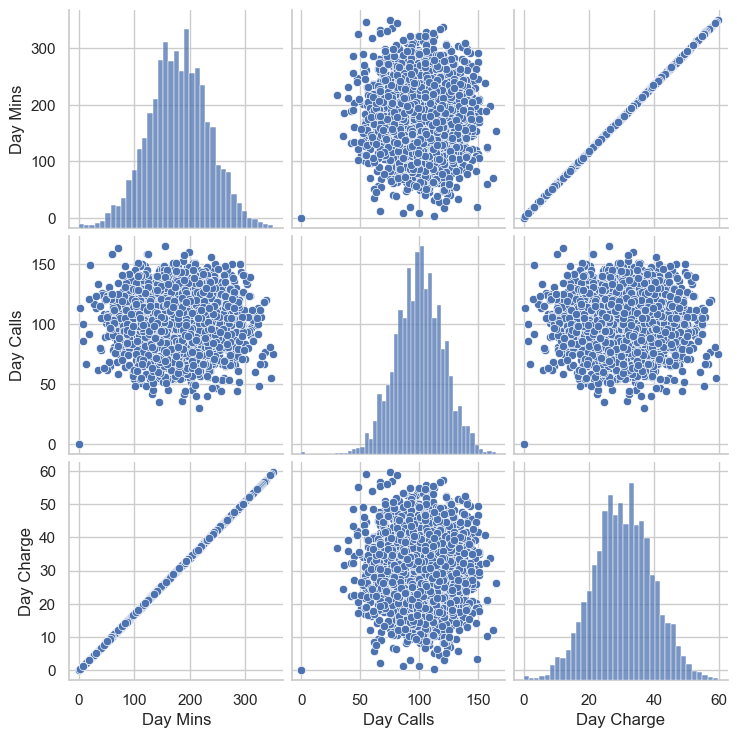

In [73]:

sns.pairplot(churn[["Day Mins","Day Calls","Day Charge"]])
plt.show()

Ponieważ zależność pomiędzy zmiennymi *Day Charge* i *Day Mins* jest wyrażnie liniowa, możemy zastosować tutaj **regresję liniową**.

W ogólności badamy zależność:
Day Charge = a0 + a1 * Day Mins

Jednak w tym wypadku będzie:
Day Charge = a1 * Day Mins

Współczynnik a1 interpretuje się jako koszt jednej minuty rozmowy w ciągu dnia.



### Zadanie 3. (1 pkt)

Jak myślisz? Dlaczego pominęliśmy czynnik a0? Gdybyśmy go pozostawili, to jaka by była jego interpretacja?

**Tu wpisz odpowiedź**
Przy wykonywaniu nie ma opłaty początkowej, więc a0 może wynosić 0, bo dopiero za minuty połączenia jest opłata.

In [92]:

X = churn[["Day Mins"]]
y = churn["Day Charge"]

reg = LinearRegression(fit_intercept=False)
reg.fit(X, y)

print("a1 (koszt minuty):", reg.coef_[0])


a1 (koszt minuty nocnej): 0.0450004462680477


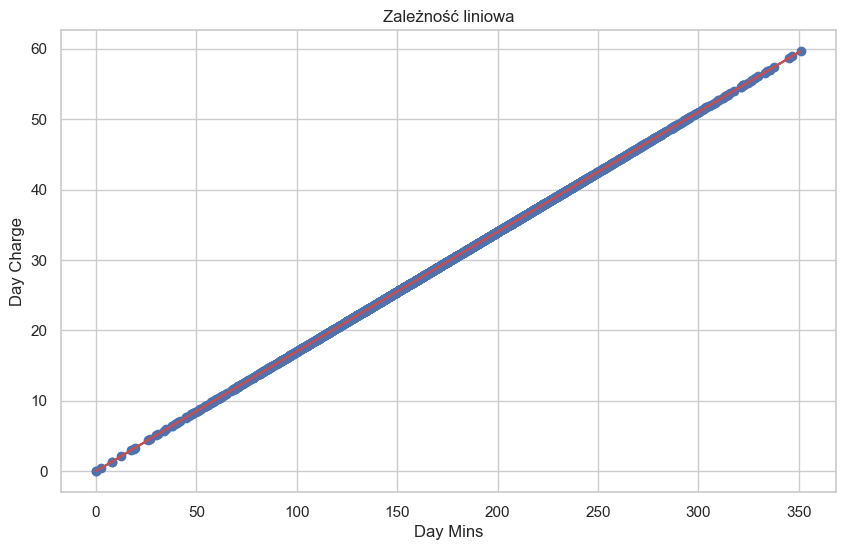

In [75]:

plt.scatter(X, y)
plt.plot(X, reg.predict(X), "r-")
plt.xlabel("Day Mins")
plt.ylabel("Day Charge")
plt.title("Zależność liniowa")
plt.show()


### Zadanie 4. (1 pkt)

Wyznacz koszt minuty rozmowy nocnej i międzynarodowej.

In [93]:
# Miejsce na odpowiedź

X = churn[["Night Mins"]]
y = churn["Night Charge"]

reg = LinearRegression(fit_intercept=False)
reg.fit(X, y)

print("a1 (koszt minuty nocnej):", reg.coef_[0])


X = churn[["Intl Mins"]]
y = churn["Intl Charge"]

reg = LinearRegression(fit_intercept=False)
reg.fit(X, y)

print("a1 (koszt minuty intl):", reg.coef_[0])



a1 (koszt minuty nocnej): 0.0450004462680477
a1 (koszt minuty intl): 0.27004583367075113



#### 6.3. Analiza skorelowanych zmiennych z wykorzystaniem regresji wielomianowej

Badamy zależność pomiędzy *mpg* i *weightlbs*.


In [77]:
cars = pd.read_csv("carsWOO.txt")
cars.columns = cars.columns.str.strip()
cars.head()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350,165,4209.0,12,1972,US.
1,17.0,8,302,140,3449.0,11,1971,US.
2,15.0,8,400,150,3761.0,10,1971,US.
3,30.5,4,98,63,2051.0,17,1978,US.
4,23.0,8,350,125,3900.0,17,1980,US.


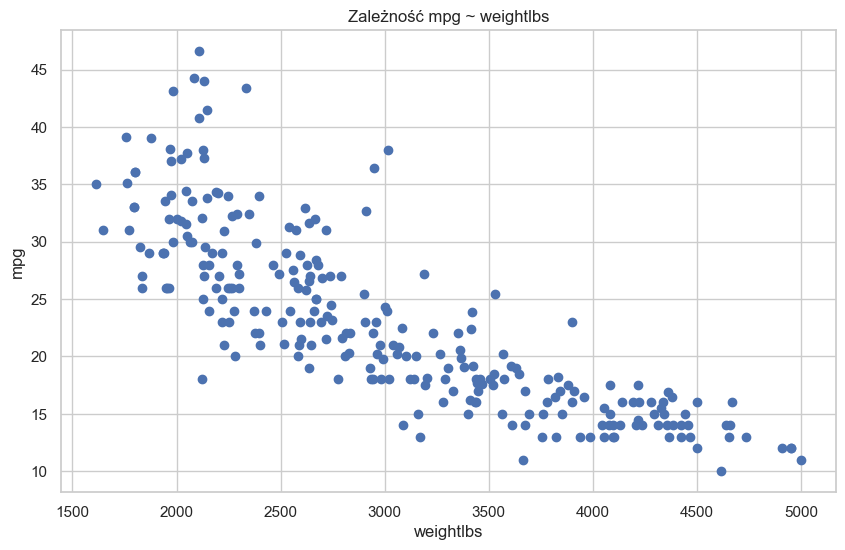

In [78]:
plt.scatter(cars["weightlbs"], cars["mpg"])
plt.xlabel("weightlbs")
plt.ylabel("mpg")
plt.title("Zależność mpg ~ weightlbs")
plt.show()

### Zadanie 5. (1 pkt)

Przeanalizuj zależność pomiędzy zmiennymi mpg i weightlbs, wykorzystując regresję liniową.

a1 (mpg a weightlbs): -0.0075702349082420895


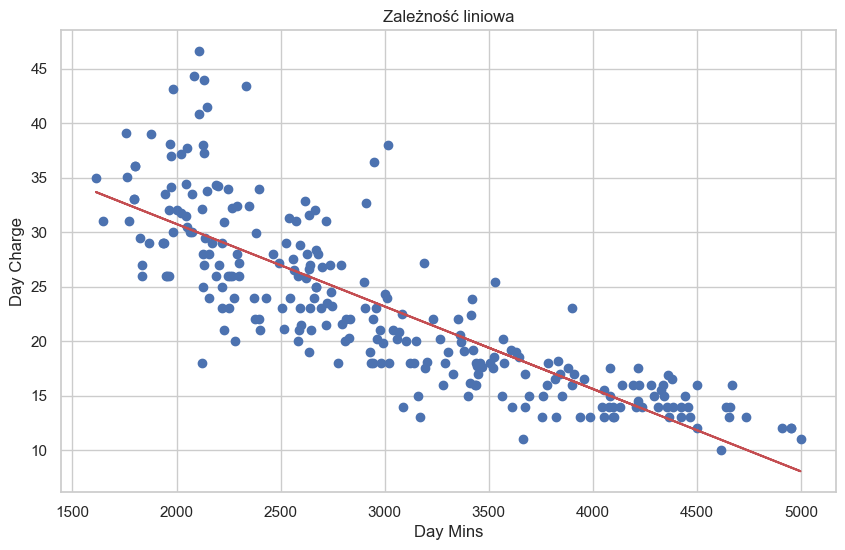

In [105]:
#Miejsce na odpowiedź
X = cars[["weightlbs"]]
y = cars["mpg"]

reg = LinearRegression(fit_intercept=True)
reg.fit(X, y)

print("a1 (mpg a weightlbs):", reg.coef_[0])

plt.scatter(X, y)
plt.plot(X, reg.predict(X), "r-")
plt.xlabel("Day Mins")
plt.ylabel("Day Charge")
plt.title("Zależność liniowa")
plt.show()


Poniższy przykład pokazuje, jak utworzyć regresję wielomianową stopnia 2.

In [80]:
X = cars[["weightlbs"]]
y = cars["mpg"]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

reg_poly = LinearRegression()
reg_poly.fit(X_poly, y)

print("Współczynniki wielomianu:", reg_poly.coef_)

Współczynniki wielomianu: [ 0.00000000e+00 -1.89636482e-02  1.78692104e-06]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


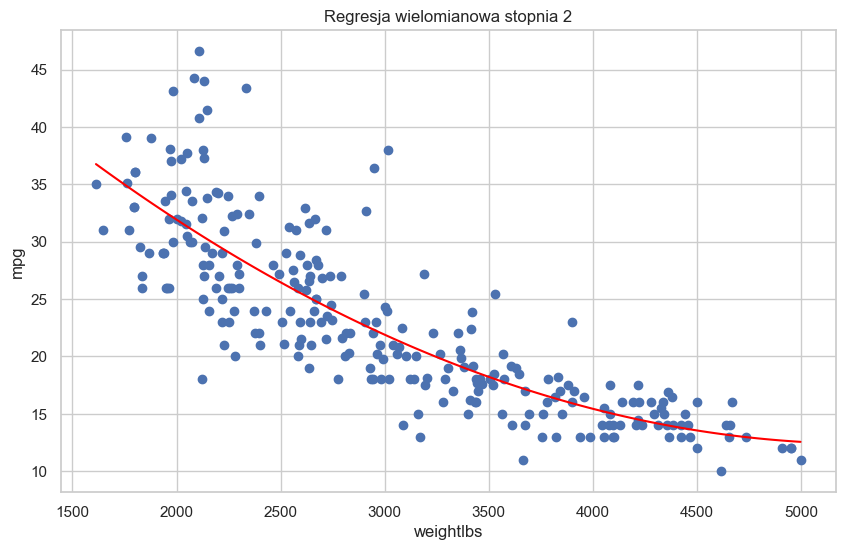

In [81]:
# tworzenie siatki do wyrysowania wielomianu
X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.scatter(X, y) # Punkty oryginalne
plt.plot(X_grid, reg_poly.predict(X_grid_poly), color='red') # Gładka krzywa
plt.xlabel("weightlbs")
plt.ylabel("mpg")
plt.title("Regresja wielomianowa stopnia 2")
plt.show()

#### 6.4. Analiza zmiennych skorelowanych dla podzbiorów zbioru uczącego

Tym razem zbadamy zależność pomiędzy *mpg* i *weightlbs* osobno dla różnych wartości zmiennej brand.

Na początek obejrzymy sobie rozkłady tych dwóch zmiennych w zależności od wartości atrybutu *brand*.


<Axes: title={'center': 'mpg'}, xlabel='brand'>

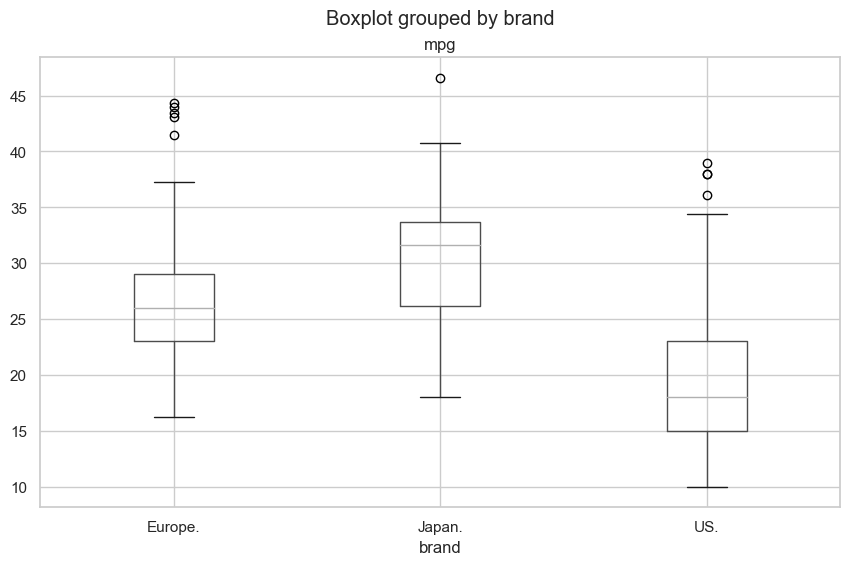

In [82]:
cars.boxplot(column="mpg",by="brand")

<Axes: title={'center': 'weightlbs'}, xlabel='brand'>

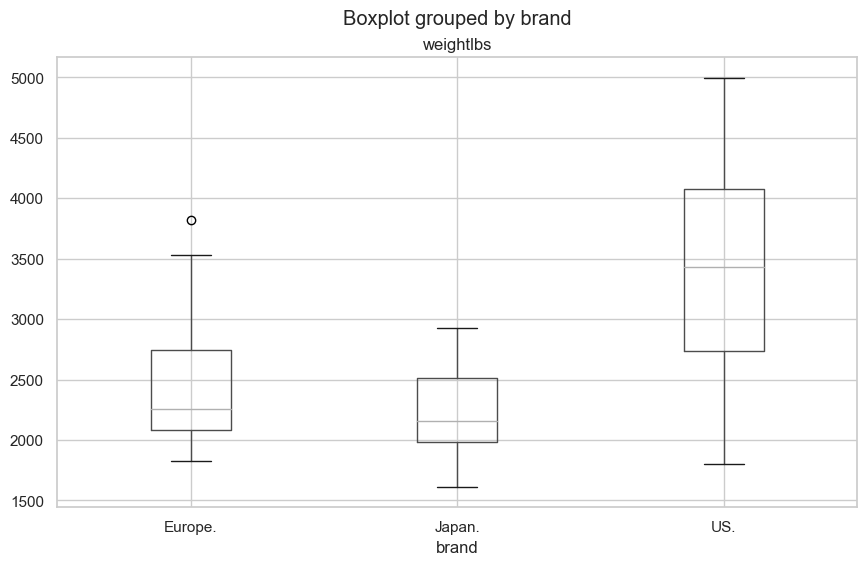

In [116]:
cars.boxplot(column="weightlbs",by="brand")

Na wykresach widoczna jest pewna zależność pomiędzy trzema atrybutami. Wyznaczymy sobie wartość korelacji dla każdej podgrupy.

In [84]:

brands = cars["brand"].unique()

for b in brands:
    subset = cars[cars["brand"] == b]
    corr, _ = spearmanr(subset["mpg"], subset["weightlbs"])
    print(f"{b}: korelacja Spearmana = {corr:.3f}")


US.: korelacja Spearmana = -0.866
Europe.: korelacja Spearmana = -0.650
Japan.: korelacja Spearmana = -0.595


### Zadanie 6. (3 pkt)

Dla każdej wartości artybutu *brand* sprawdź zależność *mpg* od *weightlbs*, wykorzystując regresję liniową i wielomianową. Który model jest lepszy? Dlaczego?

a1 (mpg a weightlbs): -0.006706010926673697


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


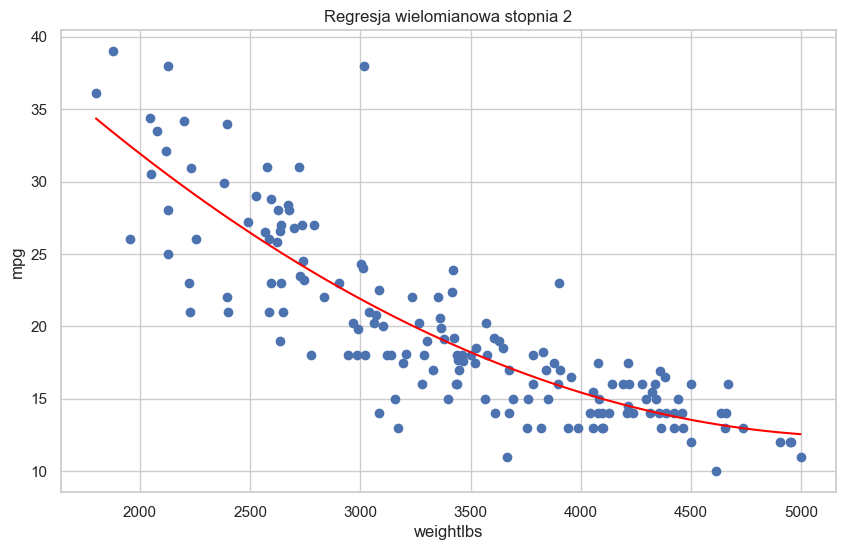

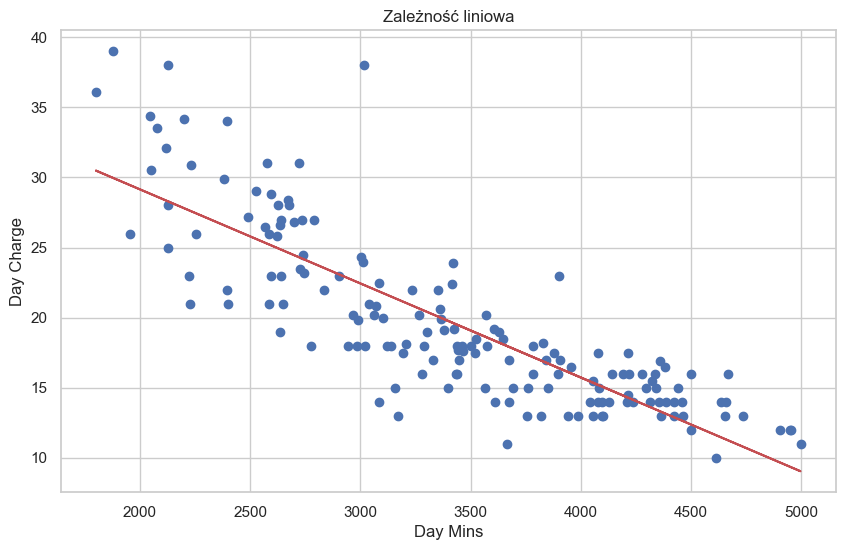

a1 (mpg a weightlbs): -0.007421996682821224


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


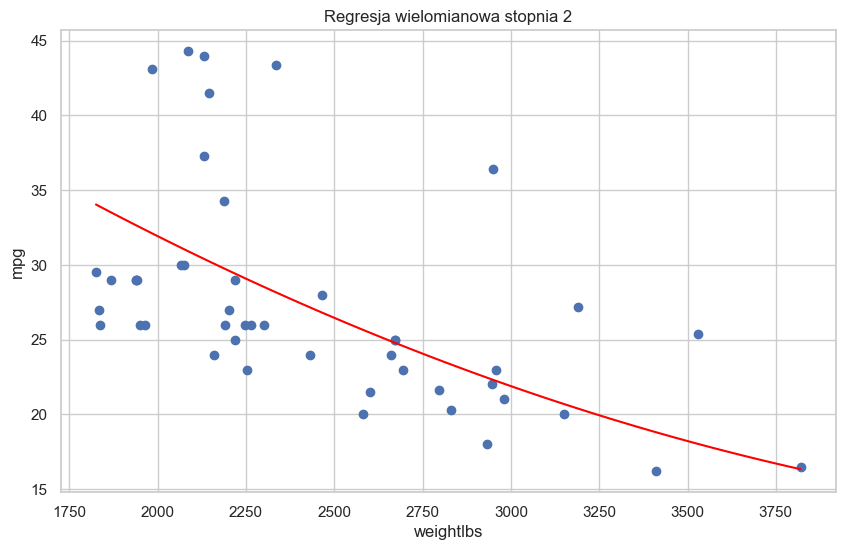

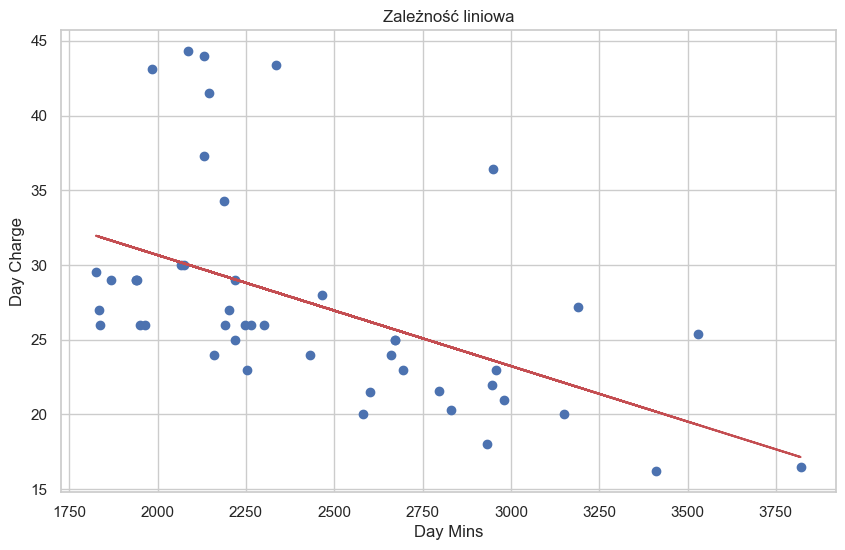

a1 (mpg a weightlbs): -0.009793177091691382


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


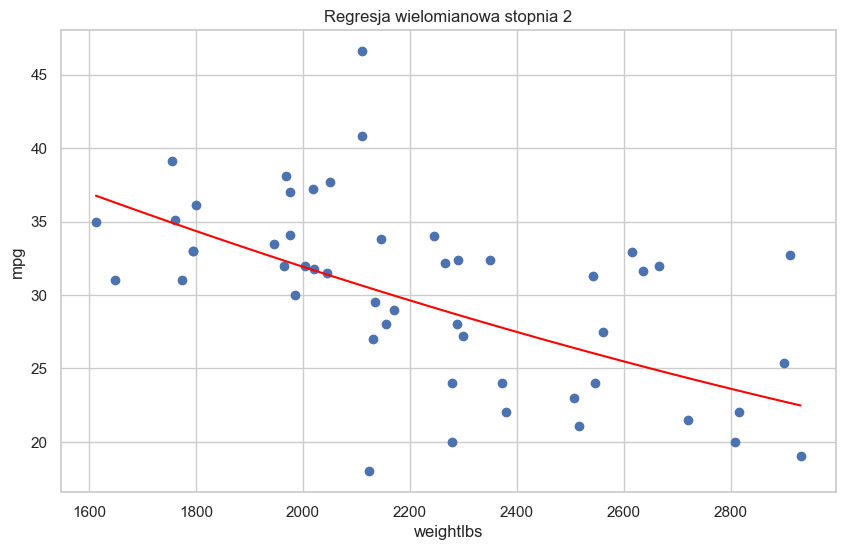

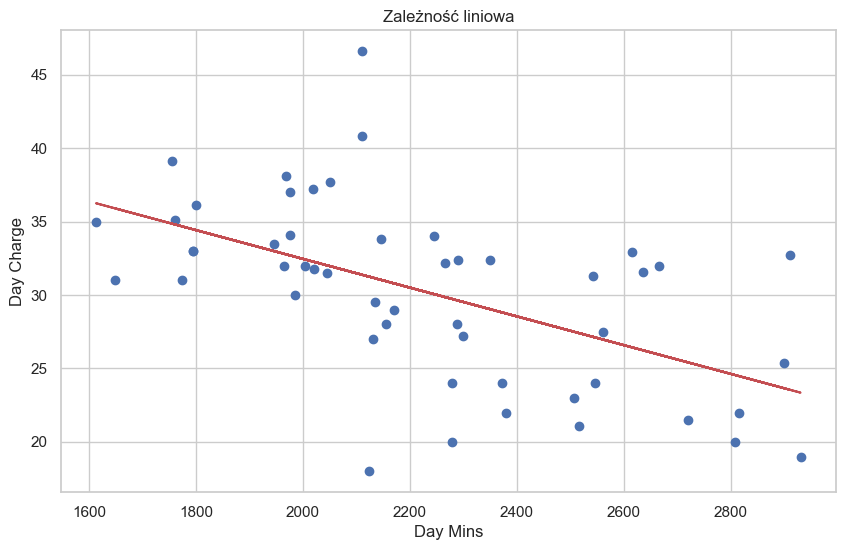

In [120]:
# Miejsce na odpowiedź
brands = cars["brand"].unique()

marki = {}

for b in brands:
    subset = cars[cars["brand"] == b]
    marki[b] = subset
    X = subset[["weightlbs"]]
    y = subset["mpg"]

    reg = LinearRegression(fit_intercept=True)
    reg.fit(X, y)

    print("a1 (mpg a weightlbs):", reg.coef_[0])
    X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_grid_poly = poly.transform(X_grid)

    plt.scatter(X, y) # Punkty oryginalne
    plt.plot(X_grid, reg_poly.predict(X_grid_poly), color='red') # Gładka krzywa
    plt.xlabel("weightlbs")
    plt.ylabel("mpg")
    plt.title("Regresja wielomianowa stopnia 2")
    plt.show()

    plt.scatter(X, y)
    plt.plot(X, reg.predict(X), "r-")
    plt.xlabel("Day Mins")
    plt.ylabel("Day Charge")
    plt.title("Zależność liniowa")
    plt.show()






### 7. Dyskretyzacja

Istnieją metody, które wymagają użycia konkretnego rodzaju atrybutu. Przykładowo regresja, k-średnie, PCA wymagają atrybutów numerycznych, natomiast algorytm Apriori atrybutów nominalnych.

Jako atrybut celu dla metod klasyfikacji również musimy podać atrybut nominalny.

---

W pliku cadata.csv znajdują się dane opisujące domy w Kalifornii (dane pochodzą z
1990 roku z roczników statystycznych). Każdy przykład opisuje jeden kwartał miejski.
Atrybuty to: mediana wartości domu (w dolarach), mediana wieku mieszkania, całkowita
liczba pomieszczeń, całkowita liczba sypialni, liczba mieszkańców, liczba gospodarstw
domowych, szerokość geograficzna i długość geograficzna.

In [86]:
cadata = pd.read_csv("cadata.csv",delimiter=";")
cadata.head()

,median house value,median income,housing median age,total rooms,total bedrooms,population,households,latitude,longitude
0,452600.0,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.2574,52.0,1467.0,190.0,496.0,177.0,37.85,-122.24
3,341300.0,5.6431,52.0,1274.0,235.0,558.0,219.0,37.85,-122.25
4,342200.0,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25


#### 7.1. Dyskretyzacja za pomocą przedziałów ustalonych przez analityka

Przedziały będziemy ustalać dla atrybutu *median house value*. 

In [87]:
bins = [0, 140000, 300000, np.inf]
labels = ["domy niedrogie", "domy drogie", "rezydencje"]

cadata["median house value"] = pd.cut(
    cadata["median house value"],
    bins=bins,
    labels=labels
)

cadata

,median house value,median income,housing median age,total rooms,total bedrooms,population,households,latitude,longitude
0,rezydencje,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,rezydencje,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,rezydencje,7.2574,52.0,1467.0,190.0,496.0,177.0,37.85,-122.24
3,rezydencje,5.6431,52.0,1274.0,235.0,558.0,219.0,37.85,-122.25
4,rezydencje,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25
...,...,...,...,...,...,...,...,...,...
20635,domy niedrogie,1.5603,25.0,1665.0,374.0,845.0,330.0,39.48,-121.09
20636,domy niedrogie,2.5568,18.0,697.0,150.0,356.0,114.0,39.49,-121.21
20637,domy niedrogie,1.7000,17.0,2254.0,485.0,1007.0,433.0,39.43,-121.22
20638,domy niedrogie,1.8672,18.0,1860.0,409.0,741.0,349.0,39.43,-121.32


Sprawdźmy teraz liczbę domów dla poszczególnych kategorii.

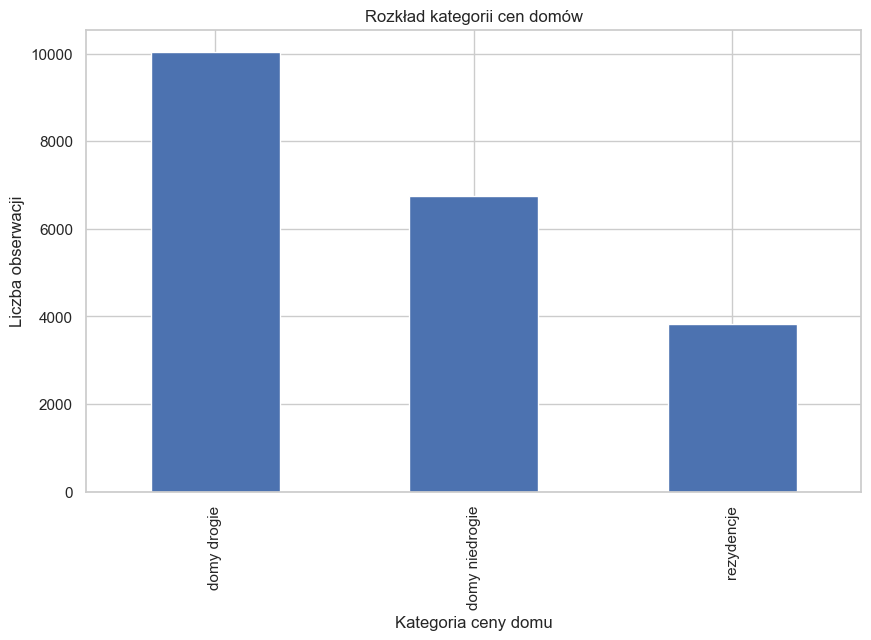

In [123]:

cadata["median house value"].value_counts().plot(kind="bar")

plt.xlabel("Kategoria ceny domu")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład kategorii cen domów")

plt.show()

### Zadanie 7. (1 pkt)

Zaproponuj inne granice dyskretyzacji i uzasadnij ich wybór. Zwizualizuj wartości wystąpień nowych kategorii.

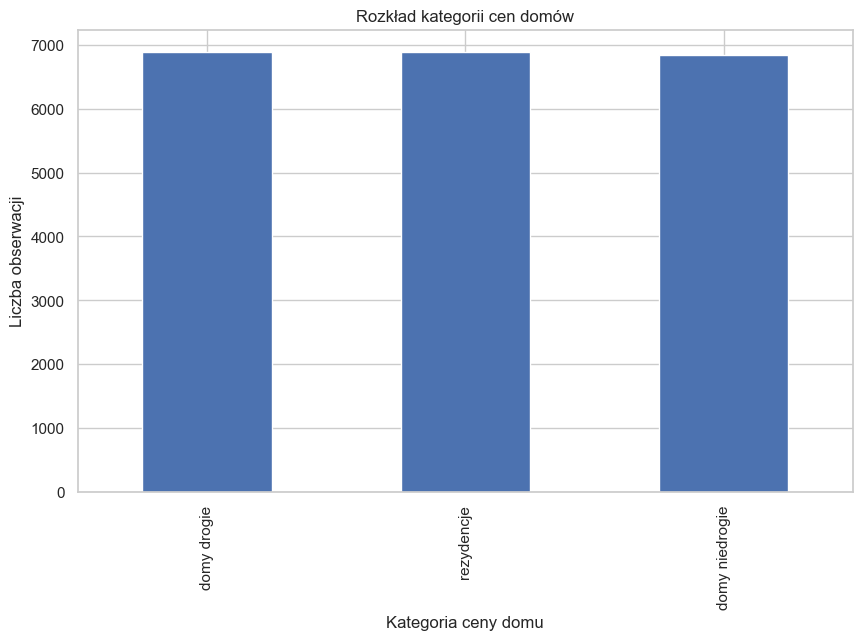

In [127]:
# Miejsce na odpowiedź

cadata = pd.read_csv("cadata.csv",delimiter=";")

bins = [0, 141000, 230000, np.inf]
labels = ["domy niedrogie", "domy drogie", "rezydencje"]

cadata["median house value"] = pd.cut(
    cadata["median house value"],
    bins=bins,
    labels=labels
)

cadata["median house value"].value_counts().plot(kind="bar")

plt.xlabel("Kategoria ceny domu")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład kategorii cen domów")

plt.show()

# wszystkie kategorie rozkładają się po równo

#### 7.2. Dyskretyzacja półautomatyczna

Tym razem ustalimy przedziały według kwantyli rozkładu.

In [121]:
cadata_original = pd.read_csv("cadata.csv",delimiter=";")

cadata_original["median house value"] = pd.qcut(
    cadata_original["median house value"],
    q=[0, 0.25, 0.5, 0.75, 1.0]
)
cadata_original

,median house value,median income,housing median age,total rooms,total bedrooms,population,households,latitude,longitude
0,"(264725.0, 500001.0]",8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,"(264725.0, 500001.0]",8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,"(264725.0, 500001.0]",7.2574,52.0,1467.0,190.0,496.0,177.0,37.85,-122.24
3,"(264725.0, 500001.0]",5.6431,52.0,1274.0,235.0,558.0,219.0,37.85,-122.25
4,"(264725.0, 500001.0]",3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25
...,...,...,...,...,...,...,...,...,...
20635,"(14998.999, 119600.0]",1.5603,25.0,1665.0,374.0,845.0,330.0,39.48,-121.09
20636,"(14998.999, 119600.0]",2.5568,18.0,697.0,150.0,356.0,114.0,39.49,-121.21
20637,"(14998.999, 119600.0]",1.7000,17.0,2254.0,485.0,1007.0,433.0,39.43,-121.22
20638,"(14998.999, 119600.0]",1.8672,18.0,1860.0,409.0,741.0,349.0,39.43,-121.32


### Zadanie 8. (1 pkt)

Porównaj rozkład klas dla dyskretyzacji ręcznej i kwantylowej. Co się zmieniło? Dlaczego?

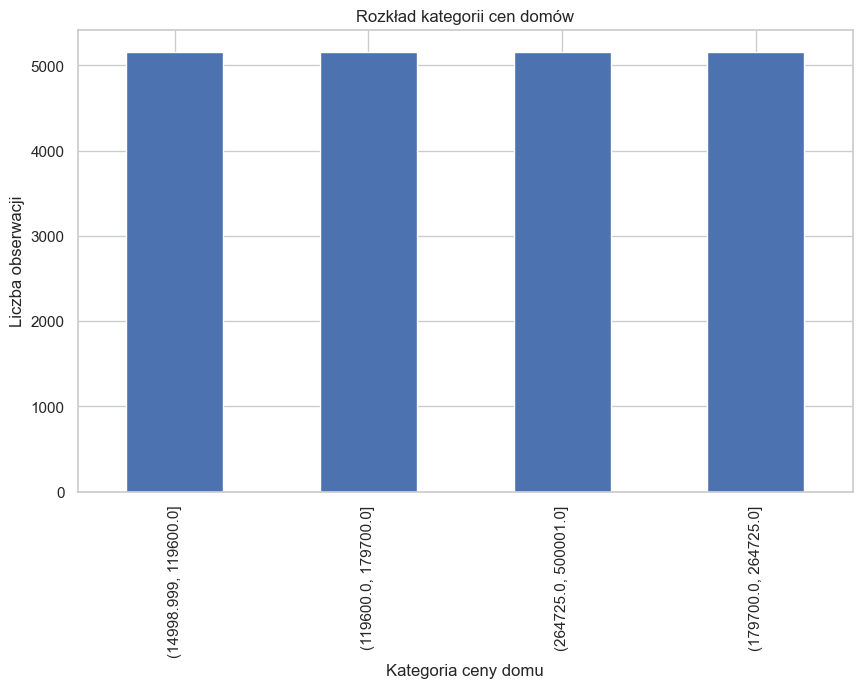

In [128]:
#Miejsce na odpowiedź
cadata_original = pd.read_csv("cadata.csv",delimiter=";")

cadata_original["median house value"] = pd.qcut(
    cadata_original["median house value"],
    q=[0, 0.25, 0.5, 0.75, 1.0]
)

labels = ["domy niedrogie", "domy drogie", "rezydencje"]


cadata_original["median house value"].value_counts().plot(kind="bar")

plt.xlabel("Kategoria ceny domu")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład kategorii cen domów")

plt.show()

# klasy rozkładają się równomiernie - "kubełki" są obliczane matematycznie. W ręcznym samemu wybierałem zakresy kubełków.
